In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# ---------- region tag from the physics you already know ----------
def region_tag(stau, zdis, amp=0.18, steep=8.0):
    """
    S-shaped interface: threshold in s bends with tau.
    amp=0 recovers the vertical line s = exp(-zdis).
    """
    s, tau = stau[:, 0], stau[:, 1]
    s0 = torch.exp(-zdis)                              # base interface location
    s_interface = s0 + amp * torch.tanh(steep * (tau - 0.5))
    return (s < s_interface).long()                    # small s = above


# ---------- lifted field: tag as an input channel, not a hard split ----------
class LiftedSurrogate(nn.Module):
    """
    5D input: [s, tau, kratio, zdis, tag]. One network, shared weights across
    both regions -- the tag=0 and tag=1 slices are learned jointly, so the
    inter-layer relationship is captured rather than hardcoded as +s.
    Mirrors your 6-layer tanh MLP.
    """
    def __init__(self, in_dim=5, nodes=256, layers=6):
        super().__init__()
        blocks, d = [], in_dim
        for _ in range(layers):
            blocks += [nn.Linear(d, nodes), nn.Tanh()]
            d = nodes
        blocks += [nn.Linear(d, 1)]
        self.net = nn.Sequential(*blocks)

    def forward(self, x5):
        return self.net(x5)                  # (N,1), matches your W target shape


# ---------- build the 5D input from your 4-key dict ----------
def build_input(d):
    """
    d: your saved dict with keys stau (N,2), W (N,1), kratio (N,), zdis (N,).
    Returns (x5, W) ready for training.
    """
    stau   = d["stau"].double()
    kratio = d["kratio"].double()
    zdis   = d["zdis"].double()
    tag    = region_tag(stau, zdis).double()

    x5 = torch.stack([stau[:, 0], stau[:, 1], kratio, zdis, tag], dim=-1)
    return x5, d["W"].double()

In [2]:
def train(model, x5, W, device="cuda", steps=20000, lr=1e-2, tol=5e-12):
    model = model.double().to(device)
    x5, W = x5.to(device), W.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, factor=0.5, patience=200)
    prev = float("inf")
    for i in range(steps):
        opt.zero_grad()
        loss = F.mse_loss(model(x5), W)
        loss.backward(); opt.step(); sched.step(loss)
        if i % 100 == 0:
            print(f"{i:6d}  mse {loss.item():.3e}  lr {opt.param_groups[0]['lr']:.1e}")
        if abs(prev - loss.item()) < tol:
            print(f"converged at {i}"); break
        prev = loss.item()
    return model


d = torch.load("data/2layer_k11.0_k22.0_nz640.pt", weights_only=True)
x5, W = build_input(d)
model = LiftedSurrogate(in_dim=5, nodes=64, layers=6)
train(model, x5, W)

     0  mse 1.088e+00  lr 1.0e-02
   100  mse 3.232e-03  lr 1.0e-02
   200  mse 5.357e-04  lr 1.0e-02
   300  mse 2.529e-04  lr 1.0e-02
   400  mse 1.954e-04  lr 1.0e-02
   500  mse 1.358e-04  lr 1.0e-02
   600  mse 1.354e-04  lr 1.0e-02
   700  mse 9.782e-05  lr 1.0e-02
   800  mse 1.232e-04  lr 1.0e-02
   900  mse 7.447e-05  lr 1.0e-02
  1000  mse 9.537e-05  lr 1.0e-02
  1100  mse 5.997e-05  lr 1.0e-02
  1200  mse 7.171e-05  lr 1.0e-02
  1300  mse 5.082e-05  lr 1.0e-02
  1400  mse 5.764e-05  lr 1.0e-02
  1500  mse 1.112e-03  lr 1.0e-02
  1600  mse 4.310e-05  lr 1.0e-02
  1700  mse 4.880e-05  lr 1.0e-02
  1800  mse 7.393e-05  lr 1.0e-02
  1900  mse 3.264e-04  lr 1.0e-02
  2000  mse 3.652e-05  lr 5.0e-03
  2100  mse 3.400e-05  lr 5.0e-03
  2200  mse 3.225e-05  lr 5.0e-03
  2300  mse 3.081e-05  lr 5.0e-03
  2400  mse 2.952e-05  lr 5.0e-03
  2500  mse 2.832e-05  lr 5.0e-03
  2600  mse 2.716e-05  lr 5.0e-03
  2700  mse 2.602e-05  lr 5.0e-03
  2800  mse 2.489e-05  lr 5.0e-03
  2900  mse 2.

LiftedSurrogate(
  (net): Sequential(
    (0): Linear(in_features=5, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): Tanh()
    (4): Linear(in_features=64, out_features=64, bias=True)
    (5): Tanh()
    (6): Linear(in_features=64, out_features=64, bias=True)
    (7): Tanh()
    (8): Linear(in_features=64, out_features=64, bias=True)
    (9): Tanh()
    (10): Linear(in_features=64, out_features=64, bias=True)
    (11): Tanh()
    (12): Linear(in_features=64, out_features=1, bias=True)
  )
)

---
## Visualization & per-region evaluation

Uses the `model`, `x5`, `W`, `d` already in memory from the cells above.
`region_tag` and `build_input` are reused as-is.

In [3]:
import numpy as np
import matplotlib.pyplot as plt

DEVICE = next(model.parameters()).device
DTYPE  = next(model.parameters()).dtype
C_ABOVE, C_BELOW = "#185FA5", "#993C1D"

# these problems share one (kratio, zdis) -- pull them from the loaded data
KRATIO = float(d["kratio"][0])
ZDIS   = float(d["zdis"][0])
print(f"kratio={KRATIO}  zdis={ZDIS}  ->  interface s = exp(-zdis) = {np.exp(-ZDIS):.4f}")

kratio=0.5  zdis=1.0  ->  interface s = exp(-zdis) = 0.3679


### Grid helpers — build the 5D input on a mesh

In [4]:
def grid_inputs(kratio, zdis, n=240):
    g = torch.linspace(1e-3, 1.0, n, dtype=DTYPE)
    S, T = torch.meshgrid(g, g, indexing="xy")
    s, t = S.reshape(-1), T.reshape(-1)
    kr = torch.full_like(s, float(kratio))
    zd = torch.full_like(s, float(zdis))
    tag = region_tag(torch.stack([s, t], dim=-1), zd).to(DTYPE)
    x5 = torch.stack([s, t, kr, zd, tag], dim=-1)
    return x5.to(DEVICE), S, T, n


@torch.no_grad()
def eval_grid(x5, n):
    return model(x5).reshape(n, n).cpu().numpy()

### Three-panel view
1. `W` over `(s, τ)` with the interface line `s = e^(-zdis)`
2. remapped to physical `z` — interface becomes vertical at `z_dis`
3. slice along `s` at fixed `τ` — the `smooth_U` kink; slope ratio measured off the model

In [5]:
@torch.no_grad()
def plot_lifted(kratio=KRATIO, zdis=ZDIS, tau_slice=0.6, n=240, zmax=None):
    model.eval()
    zmax = zmax or (zdis * 4)
    s_int = float(np.exp(-zdis))

    x5, S, T, _ = grid_inputs(kratio, zdis, n)
    Wg = eval_grid(x5, n)

    zg = torch.linspace(1e-3, zmax, n, dtype=DTYPE)
    tg = torch.linspace(1e-3, 1.0, n, dtype=DTYPE)
    Z, Tz = torch.meshgrid(zg, tg, indexing="xy")
    sz = torch.exp(-Z).reshape(-1)
    s0 = torch.exp(-zdis)                              # base interface location
    s_interface = s0 + amp * torch.tanh(steep * (tau - 0.5))
    krz = torch.full_like(sz, float(kratio)); zdz = torch.full_like(sz, float(zdis))
    tagz = region_tag(torch.stack([sz, tz], dim=-1), zdz).to(DTYPE)
    Wz = model(torch.stack([sz, tz, krz, zdz, tagz], dim=-1).to(DEVICE)).reshape(n, n).cpu().numpy()

    ss = torch.linspace(1e-3, 1.0, 500, dtype=DTYPE)
    ts = torch.full_like(ss, float(tau_slice))
    krs = torch.full_like(ss, float(kratio)); zds = torch.full_like(ss, float(zdis))
    tags = region_tag(torch.stack([ss, ts], dim=-1), zds).to(DTYPE)
    Ws = model(torch.stack([ss, ts, krs, zds, tags], dim=-1).to(DEVICE)).squeeze(-1).cpu().numpy()
    ss_np = ss.numpy()

    fig = plt.figure(figsize=(15, 4.6))

    ax1 = fig.add_subplot(1, 3, 1)
    pc1 = ax1.pcolormesh(S.numpy(), T.numpy(), Wg, cmap="viridis", shading="auto")
    ax1.axvline(s_int, color="k", lw=2)
    ax1.axhline(tau_slice, color="#D85A30", ls="--", lw=1.5)
    ax1.set_title(f"W over (s, τ) — interface s={s_int:.3f}")
    ax1.set_xlabel("s"); ax1.set_ylabel("τ")
    ax1.text(0.02, 0.94, "above (tag=1)", color=C_ABOVE, fontsize=9, transform=ax1.transAxes)
    ax1.text(0.58, 0.04, "below (tag=0)", color=C_BELOW, fontsize=9, transform=ax1.transAxes)
    fig.colorbar(pc1, ax=ax1, fraction=0.046)

    ax2 = fig.add_subplot(1, 3, 2)
    pc2 = ax2.pcolormesh(Z.numpy(), Tz.numpy(), Wz, cmap="viridis", shading="auto")
    ax2.axvline(zdis, color="k", lw=2)
    ax2.set_title("remapped to physical z")
    ax2.set_xlabel("z"); ax2.set_ylabel("t (∝ τ)")
    fig.colorbar(pc2, ax=ax2, fraction=0.046)

    ax3 = fig.add_subplot(1, 3, 3)
    ax3.axvspan(0, s_int, color=C_ABOVE, alpha=0.10)
    ax3.axvspan(s_int, 1, color=C_BELOW, alpha=0.10)
    ax3.plot(ss_np, Ws, color="#185FA5", lw=2.2)
    ax3.axvline(s_int, color="k", lw=2)
    li = np.searchsorted(ss_np, s_int)
    if 3 < li < len(ss_np) - 3:
        sl_lo = (Ws[li-1]-Ws[li-3])/(ss_np[li-1]-ss_np[li-3])
        sl_hi = (Ws[li+3]-Ws[li+1])/(ss_np[li+3]-ss_np[li+1])
        ratio = sl_lo/sl_hi if abs(sl_hi) > 1e-9 else float("nan")
        ax3.set_title(f"slice at τ={tau_slice} — slope ratio ≈ {ratio:.2f} (kratio={kratio})")
    else:
        ax3.set_title(f"slice at τ={tau_slice}")
    ax3.set_xlabel("s"); ax3.set_ylabel("W")

    plt.tight_layout(); plt.show()


plot_lifted()

TypeError: exp(): argument 'input' (position 1) must be Tensor, not float

### Predicted vs. true on the training points\nScatter of model output against the stored `W`, colored by region.

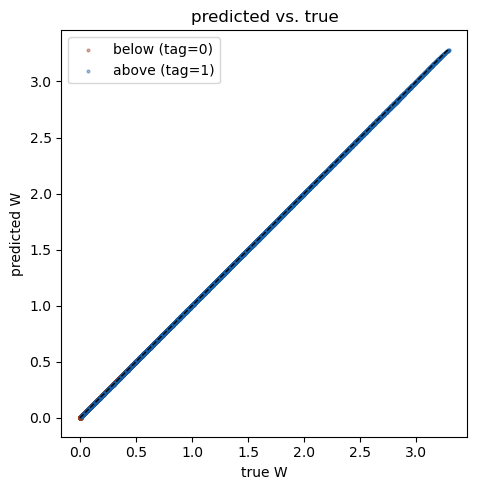

In [6]:
@torch.no_grad()
def plot_pred_vs_true():
    model.eval()
    pred = model(x5.to(DEVICE)).squeeze(-1).cpu().numpy()
    true = W.squeeze(-1).cpu().numpy()
    tag  = region_tag(d["stau"].to(DTYPE), d["zdis"].to(DTYPE)).cpu().numpy()

    fig, ax = plt.subplots(figsize=(5.2, 5))
    for t_val, c, lab in [(0, C_BELOW, "below (tag=0)"), (1, C_ABOVE, "above (tag=1)")]:
        m = tag == t_val
        ax.scatter(true[m], pred[m], s=4, c=c, alpha=0.4, label=lab)
    lo, hi = float(true.min()), float(true.max())
    ax.plot([lo, hi], [lo, hi], "k--", lw=1)
    ax.set_xlabel("true W"); ax.set_ylabel("predicted W")
    ax.set_title("predicted vs. true"); ax.legend(); ax.set_aspect("equal")
    plt.tight_layout(); plt.show()


plot_pred_vs_true()

### Per-region relative-L2 — the tag ablation number\nSplit by region. When you retrain without the tag channel (`in_dim=4`), compare these — the below-region error is where the `smooth_U` kink lives.

In [7]:
@torch.no_grad()
def region_metrics():
    model.eval()
    pred = model(x5.to(DEVICE)).cpu()
    err  = (pred - W.cpu()).squeeze(-1)
    W1   = W.cpu().squeeze(-1)
    tag  = region_tag(d["stau"].to(DTYPE), d["zdis"].to(DTYPE)).cpu()

    def rel_l2(mask):
        if mask.sum() == 0: return float("nan"), 0
        return (err[mask].norm() / W1[mask].norm()).item(), int(mask.sum())

    r_all, n_all = rel_l2(torch.ones_like(tag, dtype=torch.bool))
    r_bel, n_bel = rel_l2(tag == 0)
    r_abo, n_abo = rel_l2(tag == 1)
    print(f"relative L2   all: {r_all:.3e}  (N={n_all})")
    print(f"  below (tag=0): {r_bel:.3e}  (N={n_bel})")
    print(f"  above (tag=1): {r_abo:.3e}  (N={n_abo})")
    return {"all": r_all, "below": r_bel, "above": r_abo}


region_metrics()

relative L2   all: 1.104e-03  (N=45000)
  below (tag=0): 2.513e-03  (N=28342)
  above (tag=1): 1.000e-03  (N=16658)


{'all': 0.00110406912306246,
 'below': 0.0025127339469277333,
 'above': 0.001000348186606842}

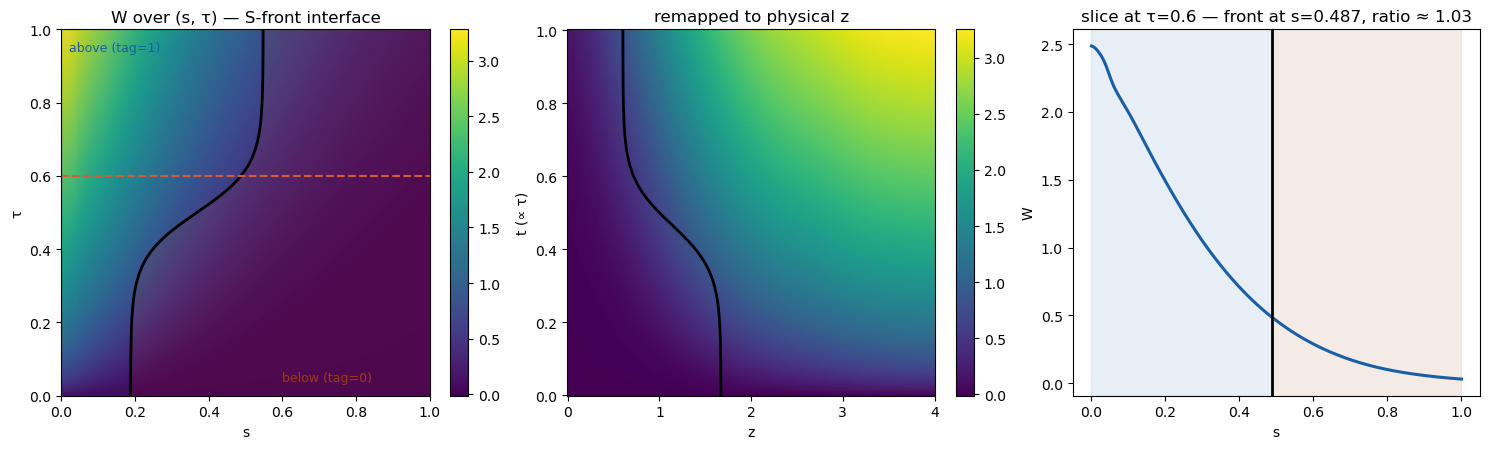

In [8]:
def front_s(tau, zdis, amp=0.18, steep=8.0):
    """Interface location in s at each tau (the moving front).
    Replace body with the front your solver produces."""
    if not torch.is_tensor(tau):
        tau = torch.as_tensor(tau, dtype=DTYPE)
    return torch.exp(-zdis) + amp * torch.tanh(steep * (tau - 0.5))


def region_tag(stau, zdis, amp=0.18, steep=8.0):
    s, tau = stau[:, 0], stau[:, 1]
    return (s < front_s(tau, zdis, amp, steep)).long()

@torch.no_grad()
def plot_lifted(kratio=KRATIO, zdis=ZDIS, tau_slice=0.6, n=240, zmax=None):
    model.eval()
    zmax = zmax or (zdis * 4)

    # --- grids ---
    x5, S, T, _ = grid_inputs(kratio, zdis, n)
    Wg = eval_grid(x5, n)

    zg = torch.linspace(1e-3, zmax, n, dtype=DTYPE)
    tg = torch.linspace(1e-3, 1.0, n, dtype=DTYPE)
    Z, Tz = torch.meshgrid(zg, tg, indexing="xy")
    sz = torch.exp(-Z).reshape(-1); tz = Tz.reshape(-1)
    krz = torch.full_like(sz, float(kratio)); zdz = torch.full_like(sz, float(zdis))
    tagz = region_tag(torch.stack([sz, tz], dim=-1), zdz).to(DTYPE)
    Wz = model(torch.stack([sz, tz, krz, zdz, tagz], dim=-1).to(DEVICE)).reshape(n, n).cpu().numpy()

    ss = torch.linspace(1e-3, 1.0, 500, dtype=DTYPE)
    ts = torch.full_like(ss, float(tau_slice))
    krs = torch.full_like(ss, float(kratio)); zds = torch.full_like(ss, float(zdis))
    tags = region_tag(torch.stack([ss, ts], dim=-1), zds).to(DTYPE)
    Ws = model(torch.stack([ss, ts, krs, zds, tags], dim=-1).to(DEVICE)).squeeze(-1).cpu().numpy()
    ss_np = ss.numpy()

    # --- the moving front, as curves in each coordinate ---
    tau_line = torch.linspace(1e-3, 1.0, 200, dtype=DTYPE)
    s_front  = front_s(tau_line, torch.tensor(float(zdis))).cpu().numpy()   # s = φ(τ)
    z_front  = -np.log(np.clip(s_front, 1e-9, None))                        # same front in z
    tau_np   = tau_line.cpu().numpy()
    s_at_slice = float(front_s(torch.tensor(float(tau_slice)),
                               torch.tensor(float(zdis))))                  # φ(τ_slice)

    fig = plt.figure(figsize=(15, 4.6))

    # panel 1: W over (s, τ) with the S-front curve + region shading
    ax1 = fig.add_subplot(1, 3, 1)
    pc1 = ax1.pcolormesh(S.numpy(), T.numpy(), Wg, cmap="viridis", shading="auto")
    ax1.plot(s_front, tau_np, "k-", lw=2)                     # S-shaped interface
    ax1.fill_betweenx(tau_np, 0, s_front, color=C_ABOVE, alpha=0.12)   # tag=1 side
    ax1.fill_betweenx(tau_np, s_front, 1, color=C_BELOW, alpha=0.12)   # tag=0 side
    ax1.axhline(tau_slice, color="#D85A30", ls="--", lw=1.5)
    ax1.set_xlim(0, 1); ax1.set_ylim(0, 1)
    ax1.set_title("W over (s, τ) — S-front interface")
    ax1.set_xlabel("s"); ax1.set_ylabel("τ")
    ax1.text(0.02, 0.94, "above (tag=1)", color=C_ABOVE, fontsize=9, transform=ax1.transAxes)
    ax1.text(0.60, 0.04, "below (tag=0)", color=C_BELOW, fontsize=9, transform=ax1.transAxes)
    fig.colorbar(pc1, ax=ax1, fraction=0.046)

    # panel 2: remapped to physical z — front becomes z = -ln(φ(τ))
    ax2 = fig.add_subplot(1, 3, 2)
    pc2 = ax2.pcolormesh(Z.numpy(), Tz.numpy(), Wz, cmap="viridis", shading="auto")
    ax2.plot(z_front, tau_np, "k-", lw=2)
    ax2.set_title("remapped to physical z")
    ax2.set_xlabel("z"); ax2.set_ylabel("t (∝ τ)")
    fig.colorbar(pc2, ax=ax2, fraction=0.046)

    # panel 3: slice at τ — interface marker at φ(τ_slice), not a fixed s
    ax3 = fig.add_subplot(1, 3, 3)
    ax3.axvspan(0, s_at_slice, color=C_ABOVE, alpha=0.10)
    ax3.axvspan(s_at_slice, 1, color=C_BELOW, alpha=0.10)
    ax3.plot(ss_np, Ws, color="#185FA5", lw=2.2)
    ax3.axvline(s_at_slice, color="k", lw=2)
    li = np.searchsorted(ss_np, s_at_slice)
    if 3 < li < len(ss_np) - 3:
        sl_lo = (Ws[li-1]-Ws[li-3])/(ss_np[li-1]-ss_np[li-3])
        sl_hi = (Ws[li+3]-Ws[li+1])/(ss_np[li+3]-ss_np[li+1])
        ratio = sl_lo/sl_hi if abs(sl_hi) > 1e-9 else float("nan")
        ax3.set_title(f"slice at τ={tau_slice} — front at s={s_at_slice:.3f}, ratio ≈ {ratio:.2f}")
    else:
        ax3.set_title(f"slice at τ={tau_slice} — front at s={s_at_slice:.3f}")
    ax3.set_xlabel("s"); ax3.set_ylabel("W")

    plt.tight_layout(); plt.show()


plot_lifted()

In [10]:
# does the tag match the front, by construction?
stau = d["stau"]
zc   = d["zdis"]
tag  = region_tag(stau, zc)
fs   = front_s(stau[:,1], zc)              # front position at each point's τ
# a point is tag=1 iff its s is left of the front
assert torch.all((stau[:,0] < fs).long() == tag), "tag disagrees with front"
print("tag matches front definition exactly")

tag matches front definition exactly
